> **Chapter 13, Part 0** | Advanced lens. **Focus:** the three streams (institutional theory, fractal-graph descriptors, AI governance) and why a single chapter braids them.

# Why Governance Needs a Fractal Lens

Three research streams converge on data governance practice without ever meeting in published literature.

1. **Institutional theory** describes pressure dynamics qualitatively. Coercive, mimetic, and normative isomorphic mechanisms shape how organizations adopt practices (DiMaggio and Powell, 1983; Meyer and Rowan, 1977; Scott, 2008; Greenwood et al., 2011).
2. **Network science and fractal graph theory** give us multi-scale graph descriptors. Box-covering on graphs (Song et al., 2005), graph fractal dimension (Skums and Bunimovich, 2020), and visibility graphs of time series (Lacasa et al., 2008) make scale-sensitivity measurable.
3. **AI governance** is the new pressure environment that intensifies all three classical isomorphic mechanisms. AI governance is fragmented and gaps between external frameworks and operational implementation are well-documented (Birkstedt et al., 2023; Mäntymäki et al., 2022; Papagiannidis et al., 2025).

Each stream is mature on its own. The intersection is empty in the published literature. Chapter 13 of this repository builds an apparatus that lives at the intersection. The chapter teaches the apparatus and names the failure modes. The companion research plan describes the validation program required to push the apparatus from prototype to peer-reviewed methodological contribution.

## Bounded claim

This chapter does not argue that every governance phenomenon is fractal. It does not argue that AI parsers replace qualitative coding by trained human analysts. It does not argue that pressure scores generated from a heuristic are equivalent to validated psychometric instruments. The chapter argues a narrower thing: that fractal-graph descriptors operationalize the multi-scale structure that institutional theory predicts but rarely measures, that AI is usefully both subject and agent in governance measurement, and that an interactive surface lets practitioners see their own pressure environment in a way text alone cannot. Where the apparatus fails, notebook 13.8 says so explicitly.

## The chapter spine

| Notebook | What it builds |
|---|---|
| 13.0 (this one) | The framing and the bounded claim. |
| 13.1 | A `PressureVector` and `Scale` model; pressure decomposition across five scales. |
| 13.2 | Decoupling as scale-dependent divergence; a `decoupling_dimension` measure. |
| 13.3 | A NetworkX governance knowledge graph with box-covering and Louvain community detection. |
| 13.4 | Visibility graphs of governance incident time series across maturity levels. |
| 13.5 | AI as governance subject (provenance graph) and agent (Anthropic-backed parser with mock fallback). |
| 13.6 | A regulation-to-action translation cascade with TF-IDF drift. |
| 13.7 | A capstone lab that combines 13.1 through 13.6 into one printable diagnostic. |
| 13.8 | The four failure modes; the honesty closer. |

## Three audiences

- **The practitioner** wants a usable apparatus for diagnosing pressure conflicts and decoupling on artifacts they describe in their own words. The capstone (13.7) is for them.
- **The researcher** wants a reproducible methods reference. The provenance graph (13.5) and the translation cascade (13.6) are for them.
- **The student** wants the theory grounded in code. The pressure-field decomposition (13.1) and the decoupling lens (13.2) are for them.

## Where this connects to earlier chapters

Chapter 11 introduced fractal descriptors as a stewardship lens. Chapter 12 generalized that lens onto graphs. Chapter 13 specializes the lens onto governance objects: pressure fields, knowledge graphs, regulation cascades, and AI provenance. The `box_cover` and `visibility_graph` functions are imported from Chapter 12 essentially unchanged. The new components are the pressure model, the decoupling-dimension measure, the AI parser with mock fallback, and the translation-cascade drift.

## Supporting reading

- DiMaggio, P. J., and Powell, W. W. (1983). The iron cage revisited. *American Sociological Review, 48*(2), 147-160.
- Meyer, J. W., and Rowan, B. (1977). Institutionalized organizations. *American Journal of Sociology, 83*(2), 340-363.
- Scott, W. R. (2008). *Institutions and organizations* (3rd ed.). SAGE.
- Greenwood, R. et al. (2011). Institutional complexity and organizational responses. *Academy of Management Annals, 5*(1), 317-371.
- Song, C., Havlin, S., and Makse, H. A. (2005). Self-similarity of complex networks. *Nature, 433*, 392-395.
- Lacasa, L. et al. (2008). From time series to complex networks. *PNAS, 105*(13), 4972-4975.
- Birkstedt, T. et al. (2023). AI governance: Themes, knowledge gaps and future agendas. *Internet Research, 33*(7), 133-167.
- Mäntymäki, M. et al. (2022). Defining organizational AI governance. *AI and Ethics, 2*(4), 603-609.
- Papagiannidis, E. et al. (2025). Responsible AI governance. *J. Strategic Information Systems, 34*(2), Article 101885.
- Malemapti Hari, D. (2026). *Static and Temporal Fractal Coupling Between Volatility and Trading Volume*. Zenodo. https://doi.org/10.5281/zenodo.19611544

## Failure note

If you finish 13.0 and still cannot say which governance question in your own work would benefit from a multi-scale measurement, the chapter has failed. The apparatus is only useful where the question is named first. Pick one before reading 13.1 and we will return to it in 13.7.


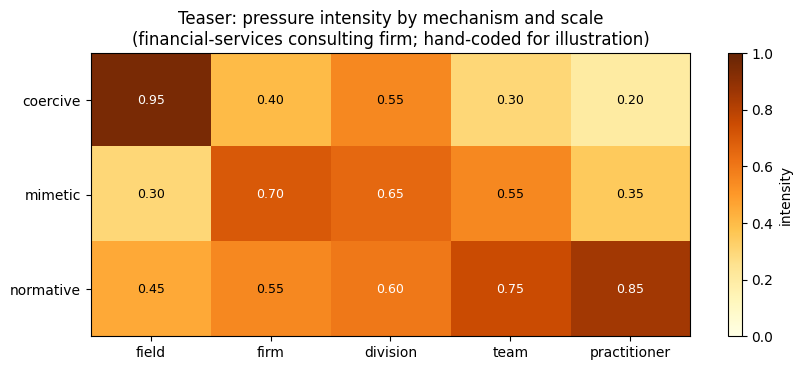


Read 13.1 to learn the PressureVector and Scale types that produce a matrix like this.
Read 13.2 to learn how decoupling shows up as scale-dependent divergence.


In [1]:
# A small teaser. Three pressure mechanisms; five scales; one tiny visualization.
# Full implementation lives in 13.1.
import numpy as np
import matplotlib.pyplot as plt

scales = ['field', 'firm', 'division', 'team', 'practitioner']
mechanisms = ['coercive', 'mimetic', 'normative']

# Hand-coded teaser values for a hypothetical financial-services consulting firm
# subject to DORA, peer benchmarking, and a strong professional code.
pressure = np.array([
    [0.95, 0.40, 0.55, 0.30, 0.20],   # coercive (regulation strongest at firm/field scale)
    [0.30, 0.70, 0.65, 0.55, 0.35],   # mimetic (peer benchmarking strongest at firm/division)
    [0.45, 0.55, 0.60, 0.75, 0.85],   # normative (professional norms strongest at practitioner)
])

fig, ax = plt.subplots(figsize=(8.6, 3.8))
im = ax.imshow(pressure, aspect='auto', cmap='YlOrBr', vmin=0, vmax=1)
ax.set_xticks(range(len(scales)))
ax.set_xticklabels(scales)
ax.set_yticks(range(len(mechanisms)))
ax.set_yticklabels(mechanisms)
for i in range(pressure.shape[0]):
    for j in range(pressure.shape[1]):
        ax.text(j, i, f'{pressure[i, j]:.2f}', ha='center', va='center',
                color='black' if pressure[i, j] < 0.6 else 'white', fontsize=9)
ax.set_title('Teaser: pressure intensity by mechanism and scale\n(financial-services consulting firm; hand-coded for illustration)')
fig.colorbar(im, ax=ax, label='intensity')
plt.tight_layout()
plt.show()

print()
print('Read 13.1 to learn the PressureVector and Scale types that produce a matrix like this.')
print('Read 13.2 to learn how decoupling shows up as scale-dependent divergence.')


## How I would debug this

Pick one governance object from your environment before reading 13.1. Examples: a model risk policy, an MDM stewardship workflow, an incident response runbook, an AI usage standard. Write down the object's name, its declared owner, and the scale at which it nominally lives. We will return to that example in 13.7. If it stays abstract, the chapter will feel abstract; if it stays concrete, the apparatus will earn its place.
